In [8]:
import os

os.environ["TORCH_HOME"] = r"D:\torch_cache"   # кэш весов torchvision/torch.hub
os.environ["TMP"] = r"D:\tmp"                  # временные файлы процесса
os.environ["TEMP"] = r"D:\tmp"                 # временные файлы процесса
os.environ["TMPDIR"] = r"D:\tmp"               # на всякий случай

# Если в ноутбуке что-то ещё скачивает/кэширует:
os.environ["KAGGLEHUB_CACHE"] = r"D:\kagglehub_cache"  # если используете kagglehub

In [3]:
import os
from pathlib import Path

# Временные файлы (pip, библиотеки, часть загрузок) — на D:
Path(r"D:\tmp").mkdir(parents=True, exist_ok=True)
os.environ["TMP"] = r"D:\tmp"
os.environ["TEMP"] = r"D:\tmp"

# Кэш pip — на D:
Path(r"D:\pip-cache").mkdir(parents=True, exist_ok=True)
os.environ["PIP_CACHE_DIR"] = r"D:\pip-cache"

# Кэш kagglehub — на D:
Path(r"D:\kagglehub_cache").mkdir(parents=True, exist_ok=True)
os.environ["KAGGLEHUB_CACHE"] = r"D:\kagglehub_cache"

# Куда складывать датасет (явно на D:)
DATASET_OUT = Path(r"D:\datasets\anime-vs-cartoon-vs-human")
DATASET_OUT.mkdir(parents=True, exist_ok=True)

print("TMP=", os.environ["TMP"])
print("KAGGLEHUB_CACHE=", os.environ["KAGGLEHUB_CACHE"])
print("DATASET_OUT=", DATASET_OUT)

TMP= D:\tmp
KAGGLEHUB_CACHE= D:\kagglehub_cache
DATASET_OUT= D:\datasets\anime-vs-cartoon-vs-human


In [9]:
'''
БЛОК 1. ПРОВЕРКА СРЕДЫ И ДАТАСЕТА (СТАРТ ЛАБОРАТОРНОЙ)

Зачем этот блок:
- Убедиться, что ноутбук использует нужный Python (kernel ml311) и что PyTorch/torchvision импортируются.
- Зафиксировать seed для воспроизводимости дальнейших шагов (разбиение выборок, обучение).
- Задать точный путь к датасету на диске D: (папка Data с классами anime, cartoon, human).
- Проверить, что три класса на месте, и вывести статистику по числу изображений (для отчёта).

Датасет у тебя лежит здесь (найдено ранее):
D:\kaggle_cache_anime\datasets\hadiepratamatulili\anime-vs-cartoon-vs-human\versions\2\Data

Дальше по лабе: блок 2 — train/val/test split и DataLoader.
'''

from pathlib import Path  # Удобная работа с путями к файлам и папкам.
import random  # Генератор случайных чисел стандартной библиотеки Python.
import numpy as np  # Массивы и численные операции.
import pandas as pd  # Табличный вывод статистики по классам.
import matplotlib.pyplot as plt  # Графики (понадобится в следующих блоках).
import seaborn as sns  # Визуализации (понадобится в следующих блоках).

import torch  # Основная библиотека для нейросетей.
import torch.nn as nn  # Модуль слоёв (понадобится при описании своей CNN).
import torch.optim as optim  # Оптимизаторы (понадобится при обучении).
from torchvision import datasets, transforms, models  # Датасеты, аугментации, предобученные модели.

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix  # Метрики из методички.

SEED = 42  # Единое значение seed для воспроизводимости эксперимента.
random.seed(SEED)  # Фиксируем seed для модуля random.
np.random.seed(SEED)  # Фиксируем seed для NumPy.
torch.manual_seed(SEED)  # Фиксируем seed для PyTorch на CPU.
torch.cuda.manual_seed_all(SEED)  # Фиксируем seed для PyTorch на GPU (если GPU есть).

torch.backends.cudnn.deterministic = True  # Делаем поведение cuDNN более детерминированным.
torch.backends.cudnn.benchmark = False  # Отключаем авто-подбор быстрых алгоритмов ради воспроизводимости.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Выбираем устройство: GPU или CPU.
print(f"Устройство: {device}")  # Печатаем, где будут вычисления.

import sys  # Доступ к пути интерпретатора Python.
print(f"Python: {sys.executable}")  # Проверяем, что kernel — из venv ml311 (путь с D:\\venvs\\ml311\\...).
print(f"Версия: {sys.version}")  # Печатаем версию Python для отчёта/отладки.

DATA_DIR = Path(r"D:\kaggle_cache_anime\datasets\hadiepratamatulili\anime-vs-cartoon-vs-human\versions\2\Data")  # Корень датасета: внутри лежат папки классов.

assert DATA_DIR.exists(), f"Папка не найдена: {DATA_DIR}"  # Проверяем, что путь к Data существует.

expected_classes = ["anime", "cartoon", "human"]  # Ожидаемые имена классов по варианту.
found_classes = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])  # Список фактических подпапок в Data.

for cls in expected_classes:  # Проверяем наличие каждого ожидаемого класса.
    assert cls in found_classes, f"Нет папки класса '{cls}' в {DATA_DIR}"  # Явная ошибка, если класса нет.

print(f"Найденные классы: {found_classes}")  # Печатаем список классов для контроля.

image_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}  # Расширения файлов, считаемых изображениями.
class_counts = {}  # Словарь: имя класса -> количество изображений.

for cls in expected_classes:  # Обходим каждый класс для подсчёта файлов.
    cls_path = DATA_DIR / cls  # Путь к папке текущего класса.
    files = [p for p in cls_path.rglob("*") if p.is_file() and p.suffix.lower() in image_ext]  # Рекурсивно собираем изображения.
    class_counts[cls] = len(files)  # Сохраняем число изображений для класса.

stats_df = pd.DataFrame({"class": list(class_counts.keys()), "num_images": list(class_counts.values())})  # Таблица статистики.
stats_df = stats_df.sort_values("class").reset_index(drop=True)  # Сортируем строки по имени класса.
total_images = int(stats_df["num_images"].sum())  # Суммарное число изображений во всём датасете.

print("\nСтатистика по классам:")  # Заголовок блока вывода.
print(stats_df.to_string(index=False))  # Печатаем таблицу без индекса.
print(f"\nВсего изображений: {total_images}")  # Печатаем итог по количеству изображений.

class_to_idx = {cls: i for i, cls in enumerate(expected_classes)}  # Отображение имя_класса -> индекс (фиксированный порядок).
idx_to_class = {i: cls for cls, i in class_to_idx.items()}  # Обратное отображение индекс -> имя_класса.

print(f"class_to_idx: {class_to_idx}")  # Для отчёта и для согласованности с обучением/метриками.
print(f"idx_to_class: {idx_to_class}")  # Для расшифровки предсказаний и матрицы ошибок позже.

Устройство: cpu
Python: D:\venvs\ml311\Scripts\python.exe
Версия: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Найденные классы: ['anime', 'cartoon', 'human']

Статистика по классам:
  class  num_images
  anime        3004
cartoon        2913
  human        3000

Всего изображений: 8917
class_to_idx: {'anime': 0, 'cartoon': 1, 'human': 2}
idx_to_class: {0: 'anime', 1: 'cartoon', 2: 'human'}


In [10]:
for v in ["DATA_DIR","device","class_names","num_classes","SEED"]:
    print(v, v in globals())

DATA_DIR True
device True
class_names False
num_classes False
SEED True


In [11]:
'''
БЛОК 2. РАЗБИЕНИЕ ВЫБОРОК И DATALOADER

Зачем этот блок:
- Разделить изображения на train / val / test (методичка: подготовка данных и предобработка).
- Для train включить лёгкие аугментации; для val/test — только resize и нормализация (честная оценка).
- Создать DataLoader для пакетной подачи данных в модель на CPU или GPU.

Что нужно заранее (из Блока 1):
- DATA_DIR — папка с подпапками anime, cartoon, human.
- SEED — для воспроизводимого random_split.
- device — куда потом отправлять батчи (cpu или cuda).

Пропорции: 70% train, 15% val, 15% test (можно поменять константы ниже).
'''

from torch.utils.data import Dataset, DataLoader, random_split  # Подмножества датасета и загрузчики батчей.
from torchvision import datasets, transforms  # ImageFolder и преобразования изображений.
import torch  # Генератор для random_split и работа с device.

IMG_SIZE = 224  # Размер входа 224x224 (стандарт для многих pretrained-сетей).
BATCH_SIZE = 16  # На CPU лучше небольшой batch; при нехватке RAM уменьши до 8.
NUM_WORKERS = 0  # На Windows в Jupyter чаще 0, чтобы не было проблем с multiprocessing.

TRAIN_RATIO = 0.70  # Доля обучающей выборки.
VAL_RATIO = 0.15  # Доля валидационной выборки.
TEST_RATIO = 0.15  # Доля тестовой выборки.

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9  # Проверяем, что доли в сумме дают 1.

train_transform = transforms.Compose([  # Цепочка преобразований для обучения.
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Приводим изображение к фиксированному размеру.
    transforms.RandomHorizontalFlip(p=0.5),  # Случайное отражение по горизонтали (аугментация).
    transforms.RandomRotation(degrees=10),  # Небольшой случайный поворот (аугментация).
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),  # Лёгкая вариация цвета.
    transforms.ToTensor(),  # PIL -> тензор [C,H,W] с значениями в [0,1].
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация как в ImageNet (удобно для transfer learning).
])  # Конец train_transform.

eval_transform = transforms.Compose([  # Цепочка для val/test без «случайностей».
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Тот же размер, что и на train.
    transforms.ToTensor(),  # Конвертация в тензор.
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Та же нормализация, что на train.
])  # Конец eval_transform.

full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=None)  # Читаем датасет по папкам классов; transform применим позже.

num_samples = len(full_dataset)  # Общее число изображений.
num_train = int(num_samples * TRAIN_RATIO)  # Число объектов в train.
num_val = int(num_samples * VAL_RATIO)  # Число объектов в val.
num_test = num_samples - num_train - num_val  # Остаток в test (чтобы сумма совпала с num_samples).

generator = torch.Generator().manual_seed(SEED)  # Локальный генератор с фиксированным seed для split.

train_subset, val_subset, test_subset = random_split(  # Случайное разбиение индексов на три части.
    full_dataset,  # Исходный датасет без transform на уровне ImageFolder.
    [num_train, num_val, num_test],  # Размеры частей.
    generator=generator,  # Воспроизводимое разбиение.
)  # Получаем три Subset с общими исходными данными.

class TransformSubset(Dataset):  # Обёртка: разным subset задаём разные transform.
    def __init__(self, subset, transform=None):  # subset — результат random_split; transform — train или eval.
        self.subset = subset  # Сохраняем ссылку на Subset.
        self.transform = transform  # Сохраняем функцию преобразования изображения.
    def __len__(self):  # Длина датасета для DataLoader.
        return len(self.subset)  # Совпадает с длиной Subset.
    def __getitem__(self, idx):  # Получение пары (картинка, метка) по индексу.
        img, y = self.subset[idx]  # img — PIL Image, y — целочисленная метка класса.
        if self.transform is not None:  # Если задан transform.
            img = self.transform(img)  # Применяем transform к PIL-изображению.
        return img, y  # Возвращаем тензор изображения и метку.

train_ds = TransformSubset(train_subset, transform=train_transform)  # Train с аугментациями.
val_ds = TransformSubset(val_subset, transform=eval_transform)  # Val только resize+normalize.
test_ds = TransformSubset(test_subset, transform=eval_transform)  # Test только resize+normalize.

train_loader = DataLoader(  # Загрузчик train.
    train_ds,  # Датасет обучения.
    batch_size=BATCH_SIZE,  # Размер мини-батча.
    shuffle=True,  # Перемешивать батчи на каждой эпохе.
    num_workers=NUM_WORKERS,  # Число фоновых процессов (0 для простоты на Windows).
    pin_memory=False,  # pin_memory=True имеет смысл в основном при CUDA.
)  # Конец train_loader.

val_loader = DataLoader(  # Загрузчик val.
    val_ds,  # Датасет валидации.
    batch_size=BATCH_SIZE,  # Тот же batch_size для единообразия.
    shuffle=False,  # На val/test перемешивание не нужно.
    num_workers=NUM_WORKERS,  # То же число воркеров.
    pin_memory=False,  # Без pin_memory на CPU.
)  # Конец val_loader.

test_loader = DataLoader(  # Загрузчик test.
    test_ds,  # Датасет теста.
    batch_size=BATCH_SIZE,  # Тот же batch_size.
    shuffle=False,  # Фиксированный порядок для воспроизводимости метрик.
    num_workers=NUM_WORKERS,  # То же число воркеров.
    pin_memory=False,  # Без pin_memory на CPU.
)  # Конец test_loader.

class_names = full_dataset.classes  # Список имён классов в алфавитном порядке (как в ImageFolder).
num_classes = len(class_names)  # Число классов (должно быть 3).

print(f"Классы ImageFolder: {class_names}")  # Печатаем порядок классов ImageFolder.
print(f"Число классов: {num_classes}")  # Печатаем число классов для головы сети.
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")  # Размеры выборок после split.

imgs, labels = next(iter(train_loader))  # Берём один батч из train_loader для проверки.
imgs = imgs.to(device)  # Переносим изображения на cpu/cuda (сейчас cpu).
labels = labels.to(device)  # Переносим метки на то же устройство.

print(f"Batch images shape: {imgs.shape}")  # Ожидаемо [B, 3, IMG_SIZE, IMG_SIZE].
print(f"Batch labels shape: {labels.shape}")  # Ожидаемо [B].
print(f"dtype img: {imgs.dtype}, dtype label: {labels.dtype}")  # float для img, long для меток.

Классы ImageFolder: ['anime', 'cartoon', 'human']
Число классов: 3
Train: 6241 | Val: 1337 | Test: 1339
Batch images shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])
dtype img: torch.float32, dtype label: torch.int64


In [12]:
for v in ["DATA_DIR","device","class_names","num_classes","train_loader","val_loader","test_loader"]:
  print(v, v in globals())

DATA_DIR True
device True
class_names True
num_classes True
train_loader True
val_loader True
test_loader True


Epoch 1/5 | train_loss=1.0750 acc=0.9356 | val_loss=0.0501 acc=0.9828 | time=520.5s
Epoch 2/5 | train_loss=0.1093 acc=0.9715 | val_loss=0.0126 acc=0.9948 | time=469.3s
Epoch 3/5 | train_loss=0.0784 acc=0.9768 | val_loss=0.0068 acc=0.9978 | time=461.1s
Epoch 4/5 | train_loss=0.0901 acc=0.9763 | val_loss=0.0260 acc=0.9903 | time=455.1s
Epoch 5/5 | train_loss=0.0481 acc=0.9867 | val_loss=0.0076 acc=0.9985 | time=457.6s
Loaded best weights with val_loss=0.0068


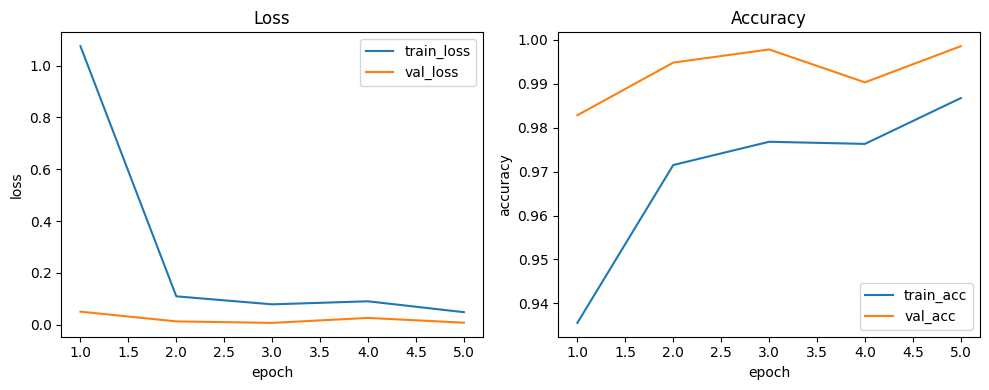

Saved: D:\lab2_baseline_cnn.pt


In [10]:
'''
БЛОК 3. СВОЯ СВЕРТОЧНАЯ СЕТЬ (BASELINE) И ОБУЧЕНИЕ

Зачем этот блок:
- Реализовать простую CNN «с нуля» для 3 классов (требование методички).
- Обучить на train, контролировать качество на val (честная оценка без подглядывания в test).
- Сохранить веса лучшей модели по минимальному val_loss (для сравнения с pretrained позже).
- Накопить историю loss/accuracy для графиков в отчёте.

Что нужно заранее:
- train_loader, val_loader из Блока 2.
- device из Блока 1.
- num_classes = 3 (или len(class_names)).

Примечание: на CPU обучение долгое — начни с небольшого EPOCHS для проверки, потом увеличь.
'''

import time  # Для замера времени эпох (удобно в отчёте).
import copy  # Для глубокой копии state_dict лучшей модели.

import torch  # Тензоры и автоград.
import torch.nn as nn  # Слои нейросети.
import torch.nn.functional as F  # Функциональные операции (pooling и т.д.).
import torch.optim as optim  # Оптимизаторы.

import matplotlib.pyplot as plt  # Графики кривых обучения.

class SmallCNN(nn.Module):  # Простая CNN для классификации изображений 3x224x224.
    def __init__(self, num_classes):  # num_classes — число выходных классов.
        super().__init__()  # Инициализация базового класса nn.Module.
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # Свёртка 3->32 каналов, размер сохраняется (padding=1).
        self.bn1 = nn.BatchNorm2d(32)  # Нормализация по батчу для устойчивости обучения.
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # Вторая свёртка 32->64 каналов.
        self.bn2 = nn.BatchNorm2d(64)  # BatchNorm для 64 каналов.
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # Третья свёртка 64->128 каналов.
        self.bn3 = nn.BatchNorm2d(128)  # BatchNorm для 128 каналов.
        self.pool = nn.MaxPool2d(2, 2)  # Max pooling 2x2: уменьшает H и W в 2 раза после каждого применения.
        self.dropout = nn.Dropout(0.25)  # Dropout для снижения переобучения перед классификатором.
        self.fc1 = nn.Linear(128 * 28 * 28, 256)  # Полносвязный слой: после 3 pool 224->112->56->28.
        self.fc2 = nn.Linear(256, num_classes)  # Выходной слой: logits для num_classes классов.

    def forward(self, x):  # Прямой проход: x имеет форму [B, 3, 224, 224].
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # conv1 + bn + relu + pool -> [B, 32, 112, 112].
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # conv2 + bn + relu + pool -> [B, 64, 56, 56].
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # conv3 + bn + relu + pool -> [B, 128, 28, 28].
        x = torch.flatten(x, 1)  # Разворачиваем карты признаков в вектор (dim=1 сохраняет batch).
        x = self.dropout(F.relu(self.fc1(x)))  # Полносвязный слой + relu + dropout.
        x = self.fc2(x)  # Логиты без softmax (CrossEntropyLoss применит log-softmax внутри).
        return x  # Возвращаем logits формы [B, num_classes].

model_cnn = SmallCNN(num_classes=num_classes).to(device)  # Создаём модель и переносим на cpu/cuda.

criterion = nn.CrossEntropyLoss()  # Функция потерь для многоклассовой классификации.
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3)  # Adam с типичным lr для старта (при необходимости уменьши на CPU).

EPOCHS = 5  # Число эпох; для черновика поставь 1–2, для отчёта увеличь (например 10–20).

history = {  # Словарь для истории метрик по эпохам.
    "train_loss": [],  # Список среднего train loss на эпоху.
    "val_loss": [],  # Список среднего val loss на эпоху.
    "train_acc": [],  # Список train accuracy на эпоху.
    "val_acc": [],  # Список val accuracy на эпоху.
}  # Конец history.

best_val_loss = float("inf")  # Лучший (минимальный) val_loss; старт с бесконечности.
best_state = None  # Сюда сохраним лучшие веса модели.

def accuracy_from_logits(logits, y):  # Доля верных предсказаний по батчу.
    preds = torch.argmax(logits, dim=1)  # Класс с максимальным logit по строкам батча.
    return (preds == y).float().mean().item()  # Среднее по батчу как скаляр float.

def run_epoch(model, loader, train_mode):  # Одна эпоха: train_mode=True обучение, False валидация.
    if train_mode:  # Если режим обучения.
        model.train()  # Включаем dropout/batchnorm в train-режим.
    else:  # Если режим оценки.
        model.eval()  # Фиксируем batchnorm/dropout для инференса.

    total_loss = 0.0  # Сумма loss по всем батчам (до усреднения).
    total_correct = 0  # Число верно классифицированных объектов.
    total = 0  # Число всех объектов.

    for xb, yb in loader:  # Итерация по батчам DataLoader.
        xb = xb.to(device)  # Переносим изображения на устройство.
        yb = yb.to(device)  # Переносим метки на устройство.

        if train_mode:  # В обучении нужны градиенты.
            optimizer.zero_grad(set_to_none=True)  # Обнуляем градиенты (set_to_none чуть эффективнее).

        with torch.set_grad_enabled(train_mode):  # Градиенты только в train.
            logits = model(xb)  # Прямой проход модели.
            loss = criterion(logits, yb)  # Считаем loss для батча.

        if train_mode:  # Если обучаемся.
            loss.backward()  # Обратное распространение.
            optimizer.step()  # Шаг оптимизатора.

        bs = xb.size(0)  # Размер батча B.
        total_loss += loss.item() * bs  # Накопляем сумму loss, взвешенную размером батча.
        total_correct += (torch.argmax(logits, dim=1) == yb).sum().item()  # Накопляем число верных предсказаний.
        total += bs  # Накопляем число примеров.

    return total_loss / total, total_correct / total  # Средний loss и accuracy на всём loader.

for epoch in range(1, EPOCHS + 1):  # Цикл по эпохам 1..EPOCHS.
    t0 = time.time()  # Время начала эпохи.

    tr_loss, tr_acc = run_epoch(model_cnn, train_loader, train_mode=True)  # Обучающая эпоха.
    va_loss, va_acc = run_epoch(model_cnn, val_loader, train_mode=False)  # Валидационная эпоха.

    history["train_loss"].append(tr_loss)  # Сохраняем train loss.
    history["val_loss"].append(va_loss)  # Сохраняем val loss.
    history["train_acc"].append(tr_acc)  # Сохраняем train accuracy.
    history["val_acc"].append(va_acc)  # Сохраняем val accuracy.

    if va_loss < best_val_loss:  # Если улучшили val_loss.
        best_val_loss = va_loss  # Обновляем лучший val_loss.
        best_state = copy.deepcopy(model_cnn.state_dict())  # Сохраняем копию весов лучшей модели.

    dt = time.time() - t0  # Длительность эпохи в секундах.
    print(  # Печатаем сводку по эпохе.
        f"Epoch {epoch}/{EPOCHS} | "  # Номер эпохи.
        f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "  # Метрики train.
        f"val_loss={va_loss:.4f} acc={va_acc:.4f} | "  # Метрики val.
        f"time={dt:.1f}s"  # Время эпохи.
    )  # Конец print.

if best_state is not None:  # Если за эпохи было хотя бы одно валидное состояние.
    model_cnn.load_state_dict(best_state)  # Загружаем лучшие веса обратно в модель.
    print(f"Loaded best weights with val_loss={best_val_loss:.4f}")  # Сообщаем лучший val_loss.

epochs_x = range(1, EPOCHS + 1)  # Ось X для графиков: номера эпох.

plt.figure(figsize=(10, 4))  # Создаём фигуру для двух графиков рядом.
plt.subplot(1, 2, 1)  # Левый subplot: loss.
plt.plot(epochs_x, history["train_loss"], label="train_loss")  # Кривая train loss.
plt.plot(epochs_x, history["val_loss"], label="val_loss")  # Кривая val loss.
plt.xlabel("epoch")  # Подпись оси X.
plt.ylabel("loss")  # Подпись оси Y.
plt.title("Loss")  # Заголовок графика.
plt.legend()  # Легенда.

plt.subplot(1, 2, 2)  # Правый subplot: accuracy.
plt.plot(epochs_x, history["train_acc"], label="train_acc")  # Кривая train accuracy.
plt.plot(epochs_x, history["val_acc"], label="val_acc")  # Кривая val accuracy.
plt.xlabel("epoch")  # Подпись оси X.
plt.ylabel("accuracy")  # Подпись оси Y.
plt.title("Accuracy")  # Заголовок графика.
plt.legend()  # Легенда.

plt.tight_layout()  # Поджимаем отступы.
plt.show()  # Показываем графики в ноутбуке.

torch.save(  # Сохраняем артефакты baseline на диск (путь на D: по желанию).
    {  # Сохраняем словарь с полезными данными.
        "model_state": model_cnn.state_dict(),  # Веса лучшей модели (после load_state_dict).
        "history": history,  # История метрик.
        "class_names": class_names,  # Имена классов для воспроизводимости.
        "num_classes": num_classes,  # Число классов.
    },  # Конец словаря checkpoint.
    r"D:\lab2_baseline_cnn.pt",  # Путь файла checkpoint на диске D.
)  # Конец torch.save.

print("Saved:", r"D:\lab2_baseline_cnn.pt")  # Подтверждаем путь сохранения.

=== Своя CNN (test) ===
Accuracy:  0.9933
Recall (macro): 0.9933
F1 (macro):     0.9933
              precision    recall  f1-score   support

       anime     0.9977    0.9866    0.9921       448
     cartoon     0.9911    0.9955    0.9933       447
       human     0.9911    0.9977    0.9944       444

    accuracy                         0.9933      1339
   macro avg     0.9933    0.9933    0.9933      1339
weighted avg     0.9933    0.9933    0.9933      1339



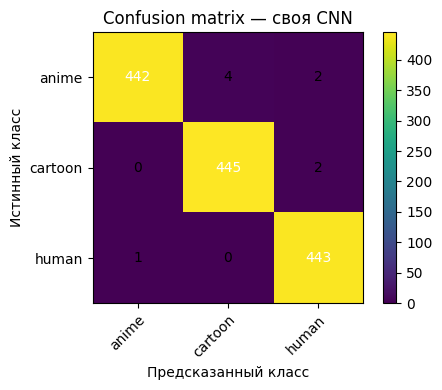

In [21]:
# Блок A: финальная оценка своей CNN на тесте (методичка: Accuracy, Recall, F1, Confusion Matrix).

import numpy as np  # Массивы для sklearn.
import torch  # Инференс на GPU/CPU.

from sklearn.metrics import (  # Метрики классификации.
    accuracy_score,  # Доля верных предсказаний.
    recall_score,  # Полнота (macro — среднее по классам без учёта поддержки весами).
    f1_score,  # F1 (macro).
    confusion_matrix,  # Матрица ошибок.
    classification_report,  # Таблица по классам.
)  # Конец импорта.

@torch.no_grad()  # На инференсе градиенты не нужны.
def collect_predictions(model, loader):  # Собираем y_true и y_pred по всему loader.
    model.eval()  # Режим оценки (dropout/bn как при тесте).
    ys, ps = [], []  # Списки меток и предсказаний.
    for xb, yb in loader:  # Батчи из test_loader.
        xb = xb.to(device)  # Изображения на устройство.
        logits = model(xb)  # Логиты [B, num_classes].
        pred = logits.argmax(dim=1).cpu().numpy()  # Класс по максимуму logit.
        ys.append(yb.numpy())  # Истинные метки (CPU).
        ps.append(pred)  # Предсказания.
    y_true = np.concatenate(ys)  # Все истинные метки.
    y_pred = np.concatenate(ps)  # Все предсказания.
    return y_true, y_pred  # Возврат для метрик.

y_true, y_pred = collect_predictions(model_cnn, test_loader)  # Прогон своей CNN на test.

acc = accuracy_score(y_true, y_pred)  # Точность на тесте.
rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)  # Recall macro.
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)  # F1 macro.

print("=== Своя CNN (test) ===")  # Заголовок.
print(f"Accuracy:  {acc:.4f}")  # Печать accuracy.
print(f"Recall (macro): {rec_macro:.4f}")  # Печать recall macro.
print(f"F1 (macro):     {f1_macro:.4f}")  # Печать F1 macro.
print(classification_report(  # Детально по классам.
    y_true,  # Истина.
    y_pred,  # Предсказания.
    target_names=class_names,  # Имена классов из блока 1.
    digits=4,  # Знаков после запятой.
))  # Конец classification_report.

cm = confusion_matrix(y_true, y_pred)  # Матрица ошибок [3x3].

import matplotlib.pyplot as plt  # График матрицы.

fig, ax = plt.subplots(figsize=(5, 4))  # Размер фигуры.
im = ax.imshow(cm, interpolation="nearest")  # Тепловая карта.
ax.figure.colorbar(im, ax=ax)  # Цветовая шкала.
ax.set(  # Подписи осей.
    xticks=np.arange(cm.shape[1]),  # Позиции по X.
    yticks=np.arange(cm.shape[0]),  # Позиции по Y.
    xticklabels=class_names,  # Имена на X.
    yticklabels=class_names,  # Имена на Y.
    ylabel="Истинный класс",  # Подпись Y.
    xlabel="Предсказанный класс",  # Подпись X.
    title="Confusion matrix — своя CNN",  # Заголовок.
)  # Конец set.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")  # Поворот подписей X.
for i in range(cm.shape[0]):  # Подписи чисел в ячейках.
    for j in range(cm.shape[1]):  # ...
        ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="w" if cm[i, j] > cm.max() / 2 else "black")  # Текст в ячейке.
fig.tight_layout()  # Отступы.
plt.show()  # Показать.

results_table = {}  # Словарь результатов для сравнения четырёх моделей.
results_table["CNN (с нуля)"] = {  # Запись для своей сети.
    "accuracy": float(acc),  # Accuracy.
    "recall_macro": float(rec_macro),  # Recall macro.
    "f1_macro": float(f1_macro),  # F1 macro.
}  # Конец записи.

In [22]:
print("results_table in globals:", "results_table" in globals())
print("results_table keys:", results_table.keys())

results_table in globals: True
results_table keys: dict_keys(['CNN (с нуля)'])


In [1]:
print("model_sn exists:", "model_sn" in globals())
print("model_rn exists:", "model_rn" in globals())
print("model_mb exists:", "model_mb" in globals())

model_sn exists: False
model_rn exists: False
model_mb exists: False


In [4]:
import os; print(os.environ.get("TORCH_HOME"))

D:\torch_cache


In [6]:
print("class_names in globals:", "class_names" in globals())
print("num_classes in globals:", "num_classes" in globals())

class_names in globals: False
num_classes in globals: False


In [14]:
print("results_table in globals:", "results_table" in globals())

results_table in globals: False


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to D:\torch_cache\hub\checkpoints\shufflenetv2_x1-5666bf0f80.pth


100%|███████████████████████████████████████████████████████████| 8.79M/8.79M [00:00<00:00, 11.2MB/s]


[ShuffleNet] frozen 1/1 train_loss=0.6980 acc=0.9407 | val_loss=0.4049 acc=0.9955 | 217.8s
[ShuffleNet] finetune 1/1 train_loss=0.0661 acc=0.9896 | val_loss=0.0025 acc=1.0000 | 318.3s
[ShuffleNet] best val_loss=0.0025
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to D:\torch_cache\hub\checkpoints\resnet50-0676ba61.pth


100%|███████████████████████████████████████████████████████████| 97.8M/97.8M [00:09<00:00, 10.8MB/s]


[ResNet50] frozen 1/1 train_loss=0.1304 acc=0.9611 | val_loss=0.0154 acc=0.9970 | 689.9s
[ResNet50] finetune 1/1 train_loss=0.0302 acc=0.9894 | val_loss=0.0045 acc=0.9978 | 1560.1s
[ResNet50] best val_loss=0.0045
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to D:\torch_cache\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|███████████████████████████████████████████████████████████| 13.6M/13.6M [00:01<00:00, 11.3MB/s]


[MobileNetV2] frozen 1/1 train_loss=0.1096 acc=0.9739 | val_loss=0.0181 acc=0.9948 | 339.6s
[MobileNetV2] finetune 1/1 train_loss=0.0164 acc=0.9944 | val_loss=0.0007 acc=1.0000 | 656.4s
[MobileNetV2] best val_loss=0.0007

=== ShuffleNet (test) ===
Accuracy: 0.9985
Recall (macro): 0.9985
F1 (macro): 0.9985
              precision    recall  f1-score   support

       anime     1.0000    0.9955    0.9978       448
     cartoon     0.9955    1.0000    0.9978       447
       human     1.0000    1.0000    1.0000       444

    accuracy                         0.9985      1339
   macro avg     0.9985    0.9985    0.9985      1339
weighted avg     0.9985    0.9985    0.9985      1339



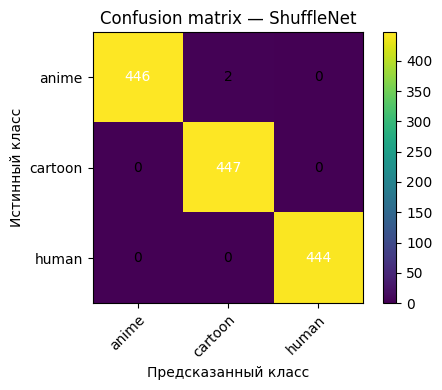


=== ResNet50 (test) ===
Accuracy: 0.9970
Recall (macro): 0.9970
F1 (macro): 0.9970
              precision    recall  f1-score   support

       anime     0.9978    1.0000    0.9989       448
     cartoon     0.9933    0.9978    0.9955       447
       human     1.0000    0.9932    0.9966       444

    accuracy                         0.9970      1339
   macro avg     0.9970    0.9970    0.9970      1339
weighted avg     0.9970    0.9970    0.9970      1339



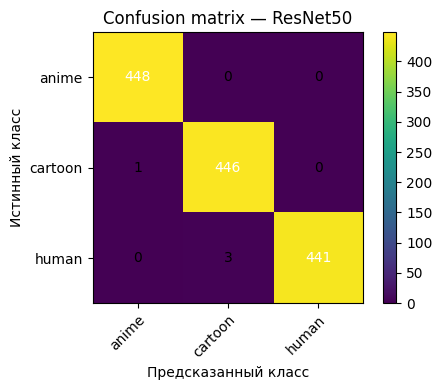


=== MobileNetV2 (test) ===
Accuracy: 0.9985
Recall (macro): 0.9985
F1 (macro): 0.9985
              precision    recall  f1-score   support

       anime     1.0000    0.9955    0.9978       448
     cartoon     0.9978    1.0000    0.9989       447
       human     0.9978    1.0000    0.9989       444

    accuracy                         0.9985      1339
   macro avg     0.9985    0.9985    0.9985      1339
weighted avg     0.9985    0.9985    0.9985      1339



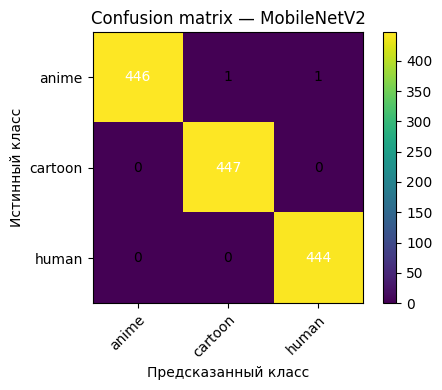


=== Сравнение моделей (по accuracy на test) ===
CNN (с нуля): accuracy=0.9933, f1_macro=0.9933
ShuffleNet: accuracy=0.9985, f1_macro=0.9985
ResNet50: accuracy=0.9970, f1_macro=0.9970
MobileNetV2: accuracy=0.9985, f1_macro=0.9985

Лучшая модель: ShuffleNet (accuracy=0.9985)


In [23]:
'''
БЛОК B (Вариант 8): Transfer Learning + оценка на test
Модели: ShuffleNet, ResNet50, MobileNetV2
Режимы: frozen backbone -> finetune (минимум эпохи)
Критерий: best по val_loss, финал оцениваем на test
'''

import copy  # для сохранения лучшего state_dict
import time  # для замеров времени

import numpy as np  # метрики/матрица ошибок
import torch  # pytorch
import torch.nn as nn  # слои
import torch.optim as optim  # оптимизаторы
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report  # метрики

import matplotlib.pyplot as plt  # графики
from torchvision import models  # предобученные сети


# Минимальные эпохи (как вы просили)
EPOCHS_FROZEN = 1  # эпоха с заморозкой
EPOCHS_FINETUNE = 1  # эпоха fine-tuning

LR_HEAD = 1e-3  # lr для головы
LR_FT = 1e-4  # lr после разморозки

criterion_tl = nn.CrossEntropyLoss()  # loss для всех моделей


def set_head_trainable(model):  # замораживаем всё, кроме классификатора (head)
    for name, p in model.named_parameters():  # перебираем все параметры
        if name.startswith("fc.") or name.startswith("classifier.1."):  # head у ResNet/ShuffleNet и линейный слой у MobileNetV2
            p.requires_grad = True  # head обучаем
        else:
            p.requires_grad = False  # backbone заморожен


def set_all_trainable(model):  # размораживаем всё
    for p in model.parameters():  # перебираем параметры
        p.requires_grad = True  # все обучаем


def get_trainable_params(model):  # получаем только параметры с requires_grad=True
    return [p for p in model.parameters() if p.requires_grad]  # список trainable параметров


@torch.no_grad()  # на валидации/тесте без градиентов (в train_mode ниже переопределяем)
def evaluate_tl(model, loader):  # оценка loss/acc на loader
    model.eval()  # eval-режим
    total_loss = 0.0  # сумма loss
    total_correct = 0  # число верных
    total = 0  # число элементов
    for xb, yb in loader:  # батчи
        xb = xb.to(device)  # на устройство
        yb = yb.to(device)  # на устройство
        logits = model(xb)  # logits
        loss = criterion_tl(logits, yb)  # loss
        bs = xb.size(0)  # размер батча
        total_loss += loss.item() * bs  # суммируем по батчам
        total_correct += (logits.argmax(1) == yb).sum().item()  # считаем верные
        total += bs  # накапливаем общее
    return total_loss / total, total_correct / total  # avg loss и accuracy


def train_one_epoch_tl(model, loader, optimizer):  # одна эпоха training
    model.train()  # train-режим (dropout/bn активны)
    total_loss = 0.0  # сумма loss
    total_correct = 0  # число верных
    total = 0  # число элементов

    for xb, yb in loader:  # батчи
        xb = xb.to(device)  # на устройство
        yb = yb.to(device)  # на устройство

        optimizer.zero_grad(set_to_none=True)  # сброс градиентов
        logits = model(xb)  # forward
        loss = criterion_tl(logits, yb)  # loss
        loss.backward()  # backward
        optimizer.step()  # шаг

        bs = xb.size(0)  # размер батча
        total_loss += loss.item() * bs  # суммируем loss
        total_correct += (logits.argmax(1) == yb).sum().item()  # считаем верные
        total += bs  # накапливаем

    return total_loss / total, total_correct / total  # avg loss и accuracy


def train_tl_model(model, model_name):  # обучаем frozen -> finetune и выбираем best по val_loss
    model = model.to(device)  # на устройство

    best_val_loss = float("inf")  # лучший val_loss
    best_state = None  # state лучшей модели

    # ---------------- frozen phase ----------------
    set_head_trainable(model)  # заморозка backbone
    optimizer = optim.Adam(get_trainable_params(model), lr=LR_HEAD)  # оптимизатор только для head

    for ep in range(1, EPOCHS_FROZEN + 1):  # цикл эпох
        t0 = time.time()  # время начала
        tr_loss, tr_acc = train_one_epoch_tl(model, train_loader, optimizer)  # train
        va_loss, va_acc = evaluate_tl(model, val_loader)  # val
        print(f"[{model_name}] frozen {ep}/{EPOCHS_FROZEN} train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={va_loss:.4f} acc={va_acc:.4f} | {time.time()-t0:.1f}s")  # лог

        if va_loss < best_val_loss:  # если лучше
            best_val_loss = va_loss  # обновляем
            best_state = copy.deepcopy(model.state_dict())  # сохраняем веса

    # ---------------- finetune phase ----------------
    set_all_trainable(model)  # разморозка всего
    optimizer = optim.Adam(model.parameters(), lr=LR_FT)  # оптимизатор на все параметры

    for ep in range(1, EPOCHS_FINETUNE + 1):  # цикл эпох
        t0 = time.time()  # время начала
        tr_loss, tr_acc = train_one_epoch_tl(model, train_loader, optimizer)  # train
        va_loss, va_acc = evaluate_tl(model, val_loader)  # val
        print(f"[{model_name}] finetune {ep}/{EPOCHS_FINETUNE} train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={va_loss:.4f} acc={va_acc:.4f} | {time.time()-t0:.1f}s")  # лог

        if va_loss < best_val_loss:  # если лучше
            best_val_loss = va_loss  # обновляем
            best_state = copy.deepcopy(model.state_dict())  # сохраняем веса

    if best_state is not None:  # на случай если вдруг
        model.load_state_dict(best_state)  # загружаем лучший checkpoint

    print(f"[{model_name}] best val_loss={best_val_loss:.4f}")  # итог
    return model  # обученная модель


def collect_predictions_tl(model, loader):  # собираем y_true/y_pred
    model.eval()  # eval-режим
    y_true, y_pred = [], []  # списки
    with torch.no_grad():  # без градиентов
        for xb, yb in loader:  # батчи
            xb = xb.to(device)  # на устройство
            logits = model(xb)  # logits
            pred = logits.argmax(1).cpu().numpy()  # предсказанные классы
            y_pred.append(pred)  # добавляем
            y_true.append(yb.numpy())  # добавляем истинные
    y_true = np.concatenate(y_true)  # склеиваем
    y_pred = np.concatenate(y_pred)  # склеиваем
    return y_true, y_pred  # возврат


def plot_confusion_matrix(cm, title):  # теплокарта confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))  # размер
    im = ax.imshow(cm, interpolation="nearest")  # теплокарта
    ax.figure.colorbar(im, ax=ax)  # шкала

    ax.set(
        xticks=np.arange(cm.shape[1]),  # позиции по X
        yticks=np.arange(cm.shape[0]),  # позиции по Y
        xticklabels=class_names,  # подписи
        yticklabels=class_names,  # подписи
        ylabel="Истинный класс",  # подпись Y
        xlabel="Предсказанный класс",  # подпись X
        title=title,  # заголовок
    )  # конец set

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")  # поворот подписей

    for i in range(cm.shape[0]):  # строки
        for j in range(cm.shape[1]):  # столбцы
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center",
                    color="w" if cm[i, j] > cm.max() / 2 else "black")  # число в клетке

    fig.tight_layout()  # подгоняем отступы
    plt.show()  # показываем


# ---------- builders (вариант 8) ----------
def build_shufflenet(num_classes_):  # ShuffleNet для 3 классов
    w = models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1  # веса ImageNet
    m = models.shufflenet_v2_x1_0(weights=w)  # модель
    in_f = m.fc.in_features  # входной размер головы
    m.fc = nn.Linear(in_f, num_classes_)  # новая голова
    return m  # модель


def build_resnet50(num_classes_):  # ResNet50 для 3 классов
    w = models.ResNet50_Weights.IMAGENET1K_V1  # веса ImageNet
    m = models.resnet50(weights=w)  # модель
    in_f = m.fc.in_features  # входной размер головы
    m.fc = nn.Linear(in_f, num_classes_)  # новая голова
    return m  # модель


def build_mobilenet_v2(num_classes_):  # MobileNetV2 для 3 классов
    w = models.MobileNet_V2_Weights.IMAGENET1K_V1  # веса ImageNet
    m = models.mobilenet_v2(weights=w)  # модель
    in_f = m.classifier[1].in_features  # вход линейного слоя классификатора
    m.classifier[1] = nn.Linear(in_f, num_classes_)  # новая голова
    return m  # модель


# ---------- обучаем 3 модели ----------
model_sn = train_tl_model(build_shufflenet(num_classes), "ShuffleNet")  # обучаем ShuffleNet
model_rn = train_tl_model(build_resnet50(num_classes), "ResNet50")  # обучаем ResNet50
model_mb = train_tl_model(build_mobilenet_v2(num_classes), "MobileNetV2")  # обучаем MobileNetV2


# ---------- тест: метрики + confusion matrix + results_table ----------
def eval_and_store(model, key_name):  # оценка на test + запись в results_table
    y_true, y_pred = collect_predictions_tl(model, test_loader)  # предсказания на test

    acc = accuracy_score(y_true, y_pred)  # accuracy
    rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)  # recall macro
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)  # f1 macro

    cm = confusion_matrix(y_true, y_pred)  # confusion matrix

    print(f"\n=== {key_name} (test) ===")  # заголовок
    print(f"Accuracy: {acc:.4f}")  # accuracy
    print(f"Recall (macro): {rec_macro:.4f}")  # recall macro
    print(f"F1 (macro): {f1_macro:.4f}")  # f1 macro
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))  # report

    plot_confusion_matrix(cm, title=f"Confusion matrix — {key_name}")  # матрица

    results_table[key_name] = {  # записываем в общую таблицу результатов
        "accuracy": float(acc),  # accuracy
        "recall_macro": float(rec_macro),  # recall macro
        "f1_macro": float(f1_macro),  # f1 macro
    }  # конец results_table


eval_and_store(model_sn, "ShuffleNet")  # тест ShuffleNet
eval_and_store(model_rn, "ResNet50")  # тест ResNet50
eval_and_store(model_mb, "MobileNetV2")  # тест MobileNetV2


# ---------- сравнение 4 моделей ----------
print("\n=== Сравнение моделей (по accuracy на test) ===")  # заголовок
best_name = max(results_table.keys(), key=lambda k: results_table[k]["accuracy"])  # имя лучшей
for k in results_table.keys():  # выводим все
    print(f"{k}: accuracy={results_table[k]['accuracy']:.4f}, f1_macro={results_table[k]['f1_macro']:.4f}")  # строка
print(f"\nЛучшая модель: {best_name} (accuracy={results_table[best_name]['accuracy']:.4f})")  # лучший итог

In [15]:
   print("model_cnn in globals:", "model_cnn" in globals())
   print("SmallCNN in globals:", "SmallCNN" in globals())

model_cnn in globals: False
SmallCNN in globals: False


In [16]:
# Новая маленькая ячейка: загрузка baseline CNN (без обучения)
# Должно появиться в globals: model_cnn

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

# На случай, если num_classes не задан (но обычно в вашем ноутбуке он уже есть)
try:
    num_classes = len(class_names)
except NameError:
    num_classes = 3

class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

baseline_path = r"D:\lab2_baseline_cnn.pt"  # путь из вашего Block A

checkpoint = torch.load(baseline_path, map_location="cpu")  # загрузка без GPU

# checkpoint может быть либо dict с ключом "model_state", либо сразу state_dict
state_dict = checkpoint.get("model_state", checkpoint)

model_cnn = SmallCNN(num_classes=num_classes).to(device)  # создаём модель
model_cnn.load_state_dict(state_dict)  # подставляем веса
model_cnn.eval()  # только инференс

print("Loaded baseline model_cnn from:", baseline_path)
print("model_cnn on device:", next(model_cnn.parameters()).device)

Loaded baseline model_cnn from: D:\lab2_baseline_cnn.pt
model_cnn on device: cpu


In [18]:
print("model_cnn in globals:", "model_cnn" in globals())
print("type(model_cnn):", type(model_cnn))
print("num_classes:", num_classes)

model_cnn in globals: True
type(model_cnn): <class '__main__.SmallCNN'>
num_classes: 3


In [19]:
model_cnn.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    xb = xb.to(device)
    logits = model_cnn(xb)
print("logits shape:", logits.shape)  # должно быть [B, 3]
print("labels shape:", yb.shape)      # должно быть [B]

logits shape: torch.Size([16, 3])
labels shape: torch.Size([16])


In [20]:
# посчитать только метрики (это не обучение)
y_true, y_pred = collect_predictions(model_cnn, test_loader)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred)
print("Test accuracy (baseline):", acc)
print("unique y_pred:", sorted(set(y_pred)))
print("unique y_true:", sorted(set(y_true)))

Test accuracy (baseline): 0.9932785660941
unique y_pred: [np.int64(0), np.int64(1), np.int64(2)]
unique y_true: [np.int64(0), np.int64(1), np.int64(2)]



СВОДКА: эффект fine-tuning (Δ val_loss = frozen → finetune, чем отрицательнее, тем лучше)
ShuffleNet    Δval_loss = -0.4024   (frozen 0.4049 → finetune 0.0025)
ResNet50      Δval_loss = -0.0109   (frozen 0.0154 → finetune 0.0045)
MobileNetV2   Δval_loss = -0.0174   (frozen 0.0181 → finetune 0.0007)

Модель: CNN (с нуля)
Число отсчётов на графике: 5
Лучший val_loss = 0.0068 на шаге 3 (индекс 3/5).
Лучший val_acc  = 0.9985 на шаге 5 (индекс 5/5).
Динамика train (первый → последний шаг):
  train_loss → train_loss: 1.0750 → 0.0481 (↓, относительно -95.5%, для метрики это лучше)
  train_acc → train_acc: 0.9356 → 0.9867 (↑, относительно +5.5%, для метрики это лучше)
Динамика val (первый → последний шаг):
  val_loss → val_loss: 0.0501 → 0.0076 (↓, относительно -84.8%, для метрики это лучше)
  val_acc → val_acc: 0.9828 → 0.9985 (↑, относительно +1.6%, для метрики это лучше)
На последнем шаге:
  train_loss − val_loss = +0.0405 (отрицательное часто бывает при сильных аугментациях на train).
  v

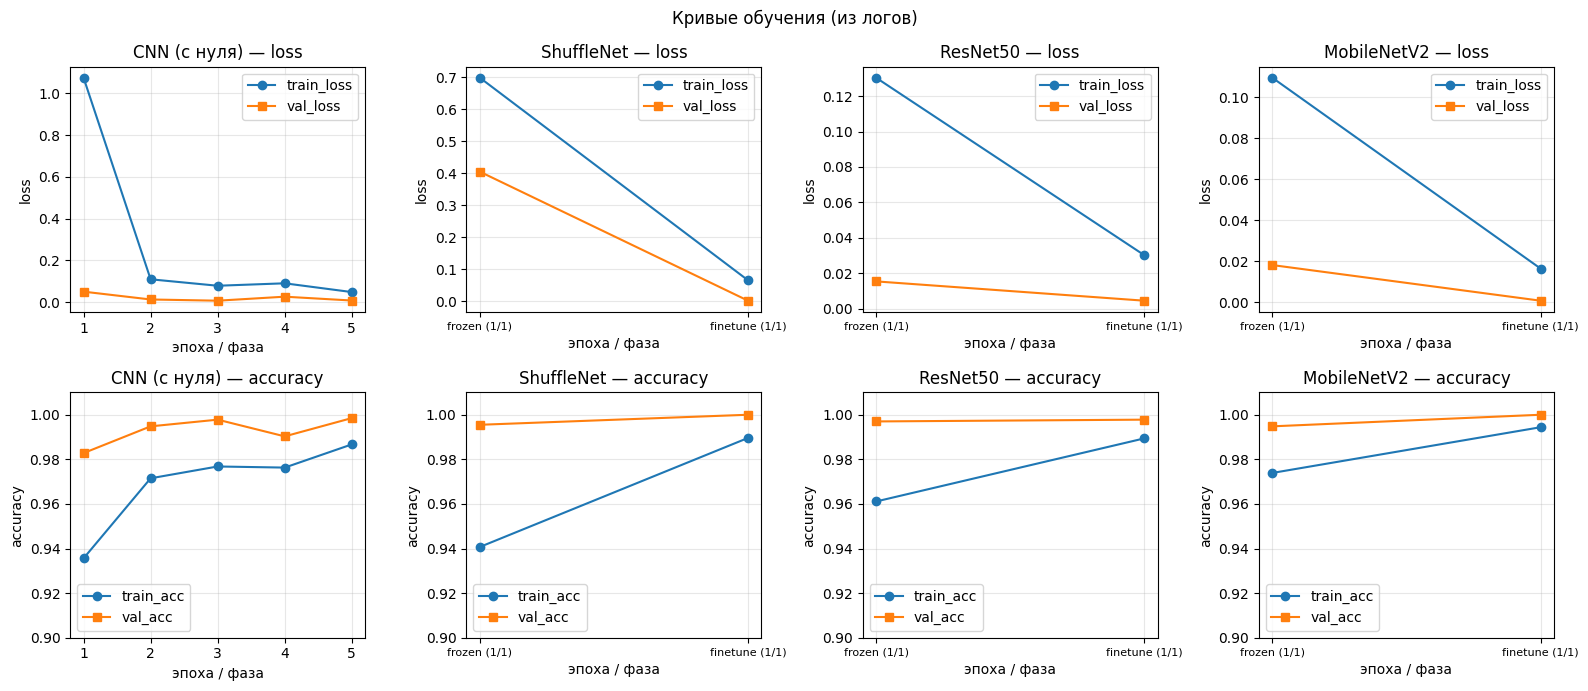

In [25]:
# Графики + текстовые выводы по сохранённым логам (без обучения)

import matplotlib.pyplot as plt
import numpy as np

# --- baseline: при наличии history из Блока 3 можно подставить автоматически ---
if "history" in globals() and isinstance(history, dict) and "train_loss" in history:
    baseline = {
        "epochs": list(range(1, len(history["train_loss"]) + 1)),
        "train_loss": list(history["train_loss"]),
        "val_loss": list(history["val_loss"]),
        "train_acc": list(history["train_acc"]),
        "val_acc": list(history["val_acc"]),
    }
else:
    baseline = {
        "epochs": [1, 2, 3, 4, 5],
        "train_loss": [1.0750, 0.1093, 0.0784, 0.0901, 0.0481],
        "val_loss": [0.0501, 0.0126, 0.0068, 0.0260, 0.0076],
        "train_acc": [0.9356, 0.9715, 0.9768, 0.9763, 0.9867],
        "val_acc": [0.9828, 0.9948, 0.9978, 0.9903, 0.9985],
    }

pretrained_histories = {
    "ShuffleNet": {
        "epochs": [1, 2],
        "epoch_labels": ["frozen (1/1)", "finetune (1/1)"],
        "train_loss": [0.6980, 0.0661],
        "val_loss": [0.4049, 0.0025],
        "train_acc": [0.9407, 0.9896],
        "val_acc": [0.9955, 1.0000],
    },
    "ResNet50": {
        "epochs": [1, 2],
        "epoch_labels": ["frozen (1/1)", "finetune (1/1)"],
        "train_loss": [0.1304, 0.0302],
        "val_loss": [0.0154, 0.0045],
        "train_acc": [0.9611, 0.9894],
        "val_acc": [0.9970, 0.9978],
    },
    "MobileNetV2": {
        "epochs": [1, 2],
        "epoch_labels": ["frozen (1/1)", "finetune (1/1)"],
        "train_loss": [0.1096, 0.0164],
        "val_loss": [0.0181, 0.0007],
        "train_acc": [0.9739, 0.9944],
        "val_acc": [0.9948, 1.0000],
    },
}

all_histories = {"CNN (с нуля)": baseline, **pretrained_histories}


def fmt_delta(a, b, name_a="начало", name_b="конец", higher_better=False):
    """Краткое описание изменения от a к b."""
    if a == 0:
        rel = float("nan")
    else:
        rel = (b - a) / abs(a) * 100.0
    direction = "↑" if b > a else ("↓" if b < a else "=")
    if higher_better:
        better = "лучше" if b > a else ("хуже" if b < a else "без изменений")
    else:
        better = "лучше" if b < a else ("хуже" if b > a else "без изменений")
    return (
        f"  {name_a} → {name_b}: {a:.4f} → {b:.4f} ({direction}, "
        f"относительно {rel:+.1f}%, для метрики это {better})"
    )


def text_report_for_model(name, h):
    """Текстовый разбор одной модели."""
    lines = []
    lines.append(f"\n{'='*60}")
    lines.append(f"Модель: {name}")
    lines.append(f"{'='*60}")

    n = len(h["train_loss"])
    lines.append(f"Число отсчётов на графике: {n}")

    # Лучшая эпоха / фаза по val_loss и val_acc
    i_best_loss = int(np.argmin(h["val_loss"]))
    i_best_acc = int(np.argmax(h["val_acc"]))
    ep_label = (
        h["epoch_labels"][i_best_loss]
        if "epoch_labels" in h
        else str(h["epochs"][i_best_loss])
    )
    lines.append(
        f"Лучший val_loss = {h['val_loss'][i_best_loss]:.4f} "
        f"на шаге {ep_label} (индекс {i_best_loss + 1}/{n})."
    )
    ep_label_acc = (
        h["epoch_labels"][i_best_acc]
        if "epoch_labels" in h
        else str(h["epochs"][i_best_acc])
    )
    lines.append(
        f"Лучший val_acc  = {h['val_acc'][i_best_acc]:.4f} "
        f"на шаге {ep_label_acc} (индекс {i_best_acc + 1}/{n})."
    )

    # Динамика от первого к последнему шагу
    lines.append("Динамика train (первый → последний шаг):")
    lines.append(
        fmt_delta(
            h["train_loss"][0],
            h["train_loss"][-1],
            "train_loss",
            "train_loss",
            higher_better=False,
        )
    )
    lines.append(
        fmt_delta(
            h["train_acc"][0],
            h["train_acc"][-1],
            "train_acc",
            "train_acc",
            higher_better=True,
        )
    )
    lines.append("Динамика val (первый → последний шаг):")
    lines.append(
        fmt_delta(
            h["val_loss"][0],
            h["val_loss"][-1],
            "val_loss",
            "val_loss",
            higher_better=False,
        )
    )
    lines.append(
        fmt_delta(
            h["val_acc"][0],
            h["val_acc"][-1],
            "val_acc",
            "val_acc",
            higher_better=True,
        )
    )

    # Зазор train vs val на последнем шаге (типичный признак аугментаций / переобучения)
    gap_loss = h["train_loss"][-1] - h["val_loss"][-1]
    gap_acc = h["val_acc"][-1] - h["train_acc"][-1]
    lines.append("На последнем шаге:")
    lines.append(
        f"  train_loss − val_loss = {gap_loss:+.4f} "
        f"(отрицательное часто бывает при сильных аугментациях на train)."
    )
    lines.append(
        f"  val_acc − train_acc = {gap_acc:+.4f} "
        f"(положительное на train часто из‑за аугментаций и dropout)."
    )

    # Для CNN: отметить «просадку» val, если есть
    if name == "CNN (с нуля)" and n >= 3:
        for k in range(1, n):
            if h["val_loss"][k] > h["val_loss"][k - 1]:
                lines.append(
                    f"  Замечание: на эпохе {k+1} val_loss вырос относительно эпохи {k} "
                    f"({h['val_loss'][k-1]:.4f} → {h['val_loss'][k]:.4f}) — возможны колебания "
                    f"валидации / начало нестабильности."
                )

    # Для transfer: эффект finetune относительно frozen
    if "epoch_labels" in h and n == 2:
        lines.append("Интерпретация фаз transfer learning:")
        lines.append(
            f"  После frozen: val_loss={h['val_loss'][0]:.4f}, val_acc={h['val_acc'][0]:.4f}."
        )
        lines.append(
            f"  После finetune: val_loss={h['val_loss'][1]:.4f}, val_acc={h['val_acc'][1]:.4f}."
        )
        if h["val_loss"][1] < h["val_loss"][0]:
            lines.append(
                "  Fine-tuning улучшил val_loss относительно фазы с замороженным backbone."
            )
        elif h["val_loss"][1] > h["val_loss"][0]:
            lines.append(
                "  Fine-tuning ухудшил val_loss — возможен шум на val или нужен меньший lr / больше эпох только frozen."
            )
        else:
            lines.append("  Val_loss почти не изменился между фазами.")

    return "\n".join(lines)


def plot_histories(histories_dict):
    names = list(histories_dict.keys())
    n = len(names)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7), squeeze=False)

    for j, name in enumerate(names):
        h = histories_dict[name]
        ep = np.array(h["epochs"], dtype=float)

        axes[0, j].plot(ep, h["train_loss"], "o-", label="train_loss")
        axes[0, j].plot(ep, h["val_loss"], "s-", label="val_loss")
        axes[0, j].set_title(f"{name} — loss")
        axes[0, j].set_xlabel("эпоха / фаза")
        axes[0, j].set_ylabel("loss")
        axes[0, j].legend()
        axes[0, j].grid(True, alpha=0.3)
        if "epoch_labels" in h:
            axes[0, j].set_xticks(ep)
            axes[0, j].set_xticklabels(h["epoch_labels"], fontsize=8)

        axes[1, j].plot(ep, h["train_acc"], "o-", label="train_acc")
        axes[1, j].plot(ep, h["val_acc"], "s-", label="val_acc")
        axes[1, j].set_title(f"{name} — accuracy")
        axes[1, j].set_xlabel("эпоха / фаза")
        axes[1, j].set_ylabel("accuracy")
        axes[1, j].set_ylim(0.90, 1.01)
        axes[1, j].legend()
        axes[1, j].grid(True, alpha=0.3)
        if "epoch_labels" in h:
            axes[1, j].set_xticks(ep)
            axes[1, j].set_xticklabels(h["epoch_labels"], fontsize=8)

    fig.suptitle("Кривые обучения (из логов)", fontsize=12)
    fig.tight_layout()
    plt.show()


# --- 1) Текстовый отчёт по каждой модели ---
full_text = []
for name, h in all_histories.items():
    full_text.append(text_report_for_model(name, h))

# --- 2) Краткое сравнение предобученных по эффекту finetune (Δ val_loss) ---
print("\n" + "=" * 60)
print("СВОДКА: эффект fine-tuning (Δ val_loss = frozen → finetune, чем отрицательнее, тем лучше)")
print("=" * 60)
for name, h in pretrained_histories.items():
    d = h["val_loss"][1] - h["val_loss"][0]
    print(f"{name:12s}  Δval_loss = {d:+.4f}   (frozen {h['val_loss'][0]:.4f} → finetune {h['val_loss'][1]:.4f})")

print("\n".join(full_text))

# --- 3) Графики ---
plot_histories(all_histories)